# Likelihood of Stop - Agency and County Comparison (v2)

This notebook compares the likelihood of being stopped for different racial groups across
law enforcement agencies and counties in North Carolina.

**What's new in v2:**
- Uses a PostgreSQL `pg.View` (`LikelihoodOfStopSummary`) with CTEs that push aggregation and ACS joins into the database layer
- Population filters (total population > 10,000 and minority population > 100) are applied in the view itself
- A single `likelihood_comparison(level, year)` helper handles both agency and county comparisons
- County-level choropleth map for geographic visualization

In [1]:
import os
import sys
from pathlib import Path

django_project_dir = Path("../../..")
sys.path.insert(0, str(django_project_dir))
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "traffic_stops.settings.dev")
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"

import django  # noqa

django.setup()

In [2]:
import json
import warnings

import pandas as pd
import plotly
import plotly.express as px
from IPython.display import display

from nc.views.likelihood import likelihood_comparison

plotly.offline.init_notebook_mode()
warnings.filterwarnings("ignore", category=FutureWarning, module="plotly")

color_map = {
    "Asian": "#F9DC4E",
    "Black": "#551DC3",
    "Hispanic": "#D24B76",
    "Native American": "#24BC7D",
    "Other": "#999999",
    "White": "#1282A2",
}
pd.set_option("display.max_rows", 500)

## The `LikelihoodOfStopSummary` View

The `LikelihoodOfStopSummary` PostgreSQL view (defined in `nc/models.py`) uses CTEs to:

1. **Average ACS population** across all available census years per `census_profile_id` and race
2. **Aggregate stops** by year and race at both **agency** and **county** levels
3. **Join** stops with ACS populations to compute `stop_rate = stops / population`
4. **Compute** `baseline_rate` (White stop rate) and `times_likely` (ratio to baseline)
5. **Filter** to entities with total population > 10,000 and minority population > 100

The `likelihood_comparison(level, year)` helper queries this view via Django ORM.

In [3]:
# Show the view SQL for transparency
from nc.models import LIKELIHOOD_OF_STOP_SUMMARY_SQL

print(LIKELIHOOD_OF_STOP_SUMMARY_SQL)


    WITH acs AS (
        SELECT
            acs_id AS census_profile_id,
            race AS driver_race,
            AVG(population)::integer AS population,
            AVG(population_total)::integer AS total_population
        FROM nc_nccensusprofile
        GROUP BY 1, 2
    ),
    agency_yearly_stops AS (
        SELECT
            'agency' AS level,
            agency.id::text AS group_id,
            agency.name AS group_name,
            agency.census_profile_id,
            EXTRACT('year' FROM summary.date)::integer AS year,
            summary.driver_race_comb AS driver_race,
            SUM(summary.count) AS stops
        FROM nc_stopsummary summary
        JOIN nc_agency agency ON summary.agency_id = agency.id
        WHERE agency.census_profile_id != ''
        GROUP BY 1, 2, 3, 4, 5, 6
    ),
    county_yearly_stops AS (
        SELECT
            'county' AS level,
            county.id AS group_id,
            county.county_name AS group_name,
            county.census

## Agency-level comparison (all years averaged)

Shows the top 20 agency-race combinations with the highest disparity in stop rates compared to white drivers. Averages stops and population across all available years.

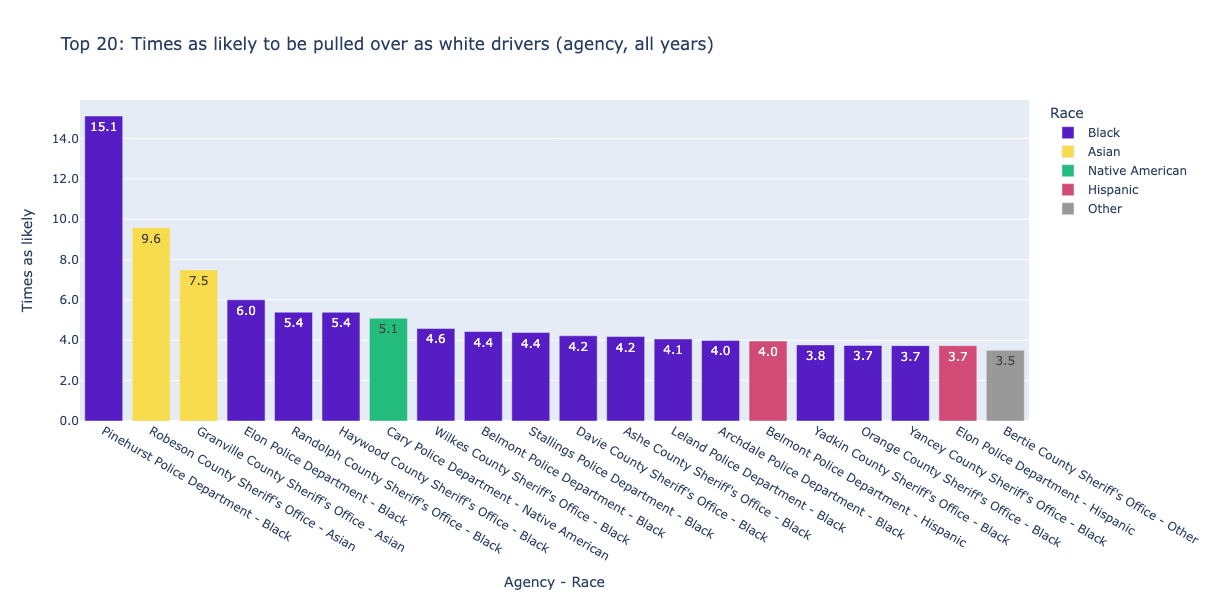

In [4]:
df_agency = likelihood_comparison(level="agency")
curr_df = df_agency[df_agency["driver_race"] != "White"].head(20)

fig = px.bar(
    curr_df,
    x="agency_name_race",
    y="times_likely",
    color="driver_race",
    color_discrete_map=color_map,
    title="Top 20: Times as likely to be pulled over as white drivers (agency, all years)",
    labels={
        "times_likely": "Times as likely",
        "driver_race": "Race",
        "agency_name_race": "Agency - Race",
    },
    text="times_likely",
    text_auto=",.1f",
    height=600,
    category_orders={"agency_name_race": curr_df["agency_name_race"].tolist()},
)
display(fig.update_yaxes(tickformat=",.1f").update_traces(textangle=0))

In [5]:
curr_df.drop(columns=["agency_name_race"])

,level,group_id,group_name,census_profile_id,driver_race,population,total_population,stops,stop_rate,baseline_rate,stop_rate_ratio,times_likely
0,agency,218,Pinehurst Police Department,1600000US3751940,Black,294,15272,502,1.707483,0.112980,14.113180,15.113180
1,agency,234,Robeson County Sheriff's Office,0500000US37155,Asian,896,130026,70,0.078125,0.008155,8.579654,9.579654
2,agency,103,Granville County Sheriff's Office,0500000US37077,Asian,311,59001,8,0.025723,0.003435,6.488389,7.488389
3,agency,321,Elon Police Department,1600000US3721095,Black,891,10058,485,0.544332,0.090636,5.005679,6.005679
4,agency,226,Randolph County Sheriff's Office,0500000US37151,Black,8046,142471,406,0.050460,0.009359,4.391854,5.391854
5,agency,112,Haywood County Sheriff's Office,0500000US37087,Black,563,59938,60,0.106572,0.019777,4.388694,5.388694
6,agency,46,Cary Police Department,1600000US3710740,Native American,450,152899,208,0.462222,0.090795,4.090827,5.090827
7,agency,305,Wilkes County Sheriff's Office,0500000US37193,Black,2772,68160,7,0.002525,0.000551,3.587083,4.587083
8,agency,22,Belmont Police Department,1600000US3704840,Black,1015,11505,568,0.559606,0.126203,3.434165,4.434165
9,agency,256,Stallings Police Department,1600000US3764420,Black,1029,14374,477,0.463557,0.105721,3.384716,4.384716


## Agency-level comparison (2023 only)

Filters to stops from 2023 and uses year-specific data from the view.

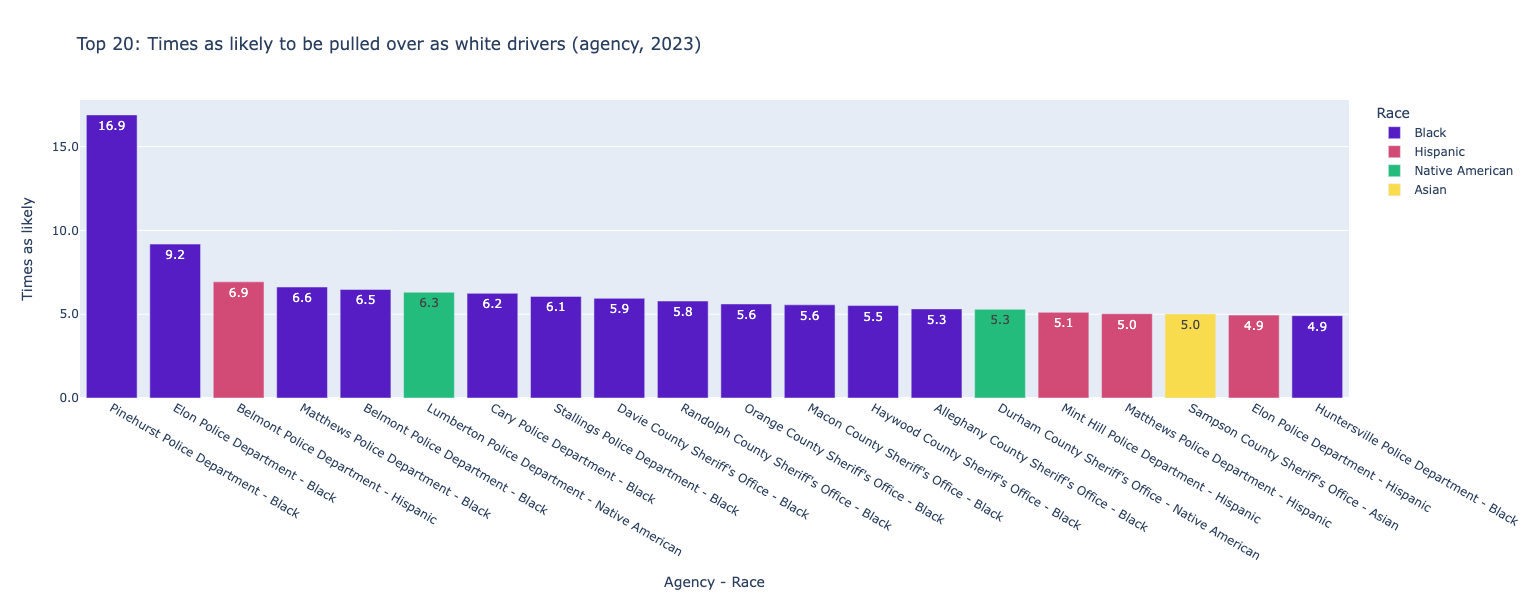

In [6]:
df_agency_2023 = likelihood_comparison(level="agency", year=2023)
curr_df = df_agency_2023[df_agency_2023["driver_race"] != "White"].head(20)

fig = px.bar(
    curr_df,
    x="agency_name_race",
    y="times_likely",
    color="driver_race",
    color_discrete_map=color_map,
    title="Top 20: Times as likely to be pulled over as white drivers (agency, 2023)",
    labels={
        "times_likely": "Times as likely",
        "driver_race": "Race",
        "agency_name_race": "Agency - Race",
    },
    text="times_likely",
    text_auto=",.1f",
    height=600,
    category_orders={"agency_name_race": curr_df["agency_name_race"].tolist()},
)
display(fig.update_yaxes(tickformat=",.1f").update_traces(textangle=0))

In [7]:
curr_df.drop(columns=["agency_name_race"])

,level,group_id,group_name,census_profile_id,year,driver_race,population,total_population,stops,stop_rate,baseline_rate,stop_rate_ratio,times_likely
0,agency,218,Pinehurst Police Department,1600000US3751940,2023,Black,294,15272,453,1.540816,0.091203,15.894341,16.894341
1,agency,321,Elon Police Department,1600000US3721095,2023,Black,891,10058,1107,1.242424,0.135294,8.183136,9.183136
2,agency,22,Belmont Police Department,1600000US3704840,2023,Hispanic,330,11505,216,0.654545,0.094439,5.930917,6.930917
3,agency,163,Matthews Police Department,1600000US3741960,2023,Black,3020,29305,1954,0.647020,0.097688,5.623317,6.623317
4,agency,22,Belmont Police Department,1600000US3704840,2023,Black,1015,11505,621,0.611823,0.094439,5.478530,6.478530
5,agency,154,Lumberton Police Department,1600000US3739700,2023,Native American,2659,20977,203,0.076344,0.012096,5.311407,6.311407
6,agency,46,Cary Police Department,1600000US3710740,2023,Black,11485,152899,3786,0.329647,0.052789,5.244674,6.244674
7,agency,256,Stallings Police Department,1600000US3764420,2023,Black,1029,14374,442,0.429543,0.070832,5.064234,6.064234
8,agency,74,Davie County Sheriff's Office,0500000US37059,2023,Black,2419,41764,462,0.190988,0.032111,4.947720,5.947720
9,agency,226,Randolph County Sheriff's Office,0500000US37151,2023,Black,8046,142471,957,0.118941,0.020555,4.786380,5.786380


## County-level comparison (all years averaged)

Aggregates stops at the county level using the `Agency → County` relationship established via pygris spatial joins.

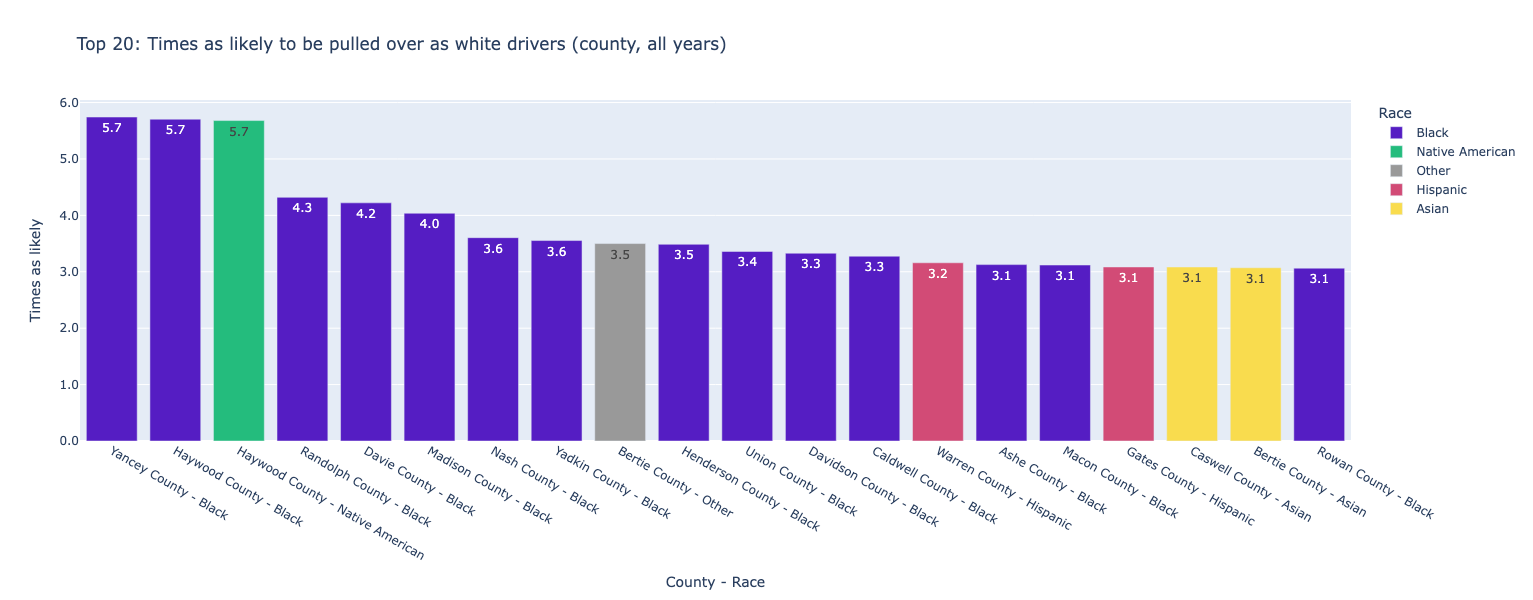

In [8]:
df_county = likelihood_comparison(level="county")
curr_df = df_county[df_county["driver_race"] != "White"].head(20)

fig = px.bar(
    curr_df,
    x="agency_name_race",
    y="times_likely",
    color="driver_race",
    color_discrete_map=color_map,
    title="Top 20: Times as likely to be pulled over as white drivers (county, all years)",
    labels={
        "times_likely": "Times as likely",
        "driver_race": "Race",
        "agency_name_race": "County - Race",
    },
    text="times_likely",
    text_auto=",.1f",
    height=600,
    category_orders={"agency_name_race": curr_df["agency_name_race"].tolist()},
)
display(fig.update_yaxes(tickformat=",.1f").update_traces(textangle=0))

In [9]:
curr_df.drop(columns=["agency_name_race"])

,level,group_id,group_name,census_profile_id,driver_race,population,total_population,stops,stop_rate,baseline_rate,stop_rate_ratio,times_likely
0,county,37199,Yancey County,0500000US37199,Black,135,17934,13,0.096296,0.016767,4.743263,5.743263
1,county,37087,Haywood County,0500000US37087,Black,563,59938,99,0.175844,0.030822,4.705151,5.705151
2,county,37087,Haywood County,0500000US37087,Native American,257,59938,45,0.175097,0.030822,4.680934,5.680934
3,county,37151,Randolph County,0500000US37151,Black,8046,142471,1454,0.180711,0.041832,3.319926,4.319926
4,county,37059,Davie County,0500000US37059,Black,2419,41764,191,0.078958,0.018701,3.222176,4.222176
5,county,37115,Madison County,0500000US37115,Black,307,21086,24,0.078176,0.019362,3.037663,4.037663
6,county,37127,Nash County,0500000US37127,Black,36427,94622,5884,0.161529,0.044812,2.604567,3.604567
7,county,37197,Yadkin County,0500000US37197,Black,1235,37790,60,0.048583,0.013671,2.553769,3.553769
8,county,37015,Bertie County,0500000US37015,Other,186,19734,2,0.010753,0.003072,2.500256,3.500256
9,county,37089,Henderson County,0500000US37089,Black,3493,110637,524,0.150014,0.043021,2.487012,3.487012


## County choropleth map - Black drivers (2023)

Interactive choropleth map showing the times-as-likely ratio for Black drivers by county. Uses the `North_Carolina.topo.json` TopoJSON file for county geometries.

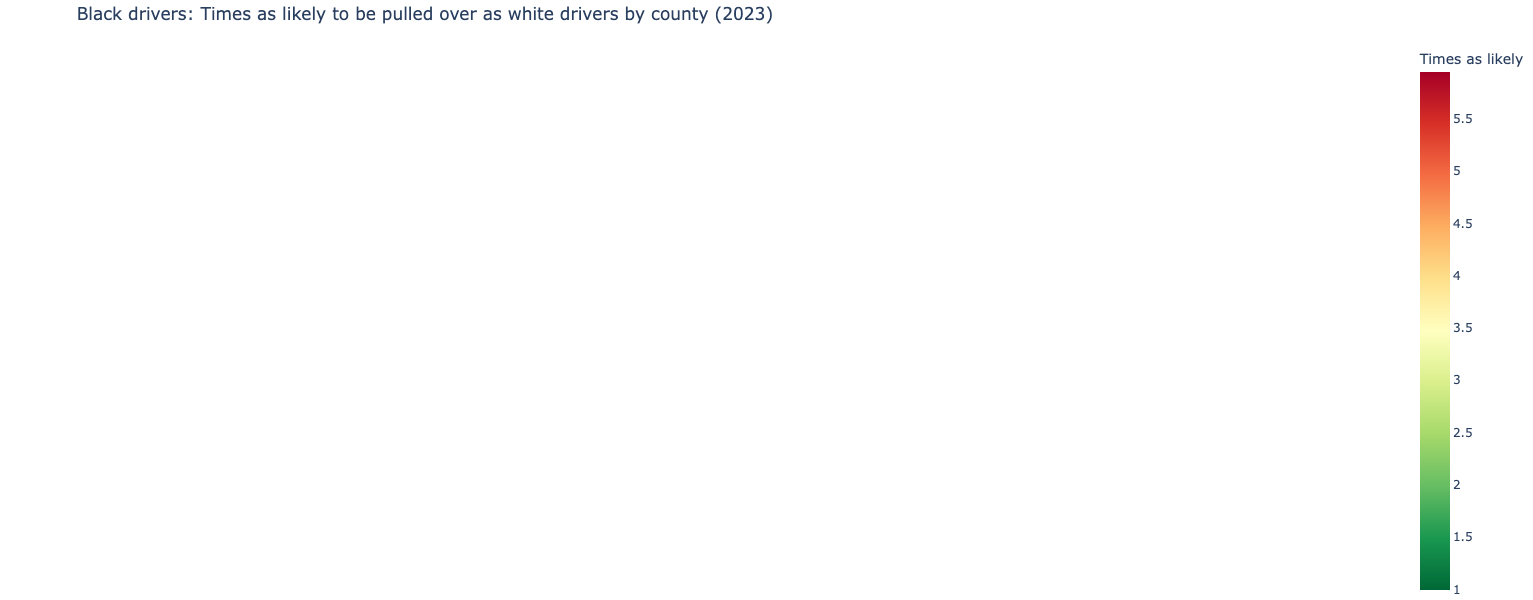

In [12]:
topo_path = django_project_dir / Path("nc/data/North_Carolina.topo.json")
with open(topo_path) as f:
    nc_topo = json.load(f)

df_county_2023 = likelihood_comparison(level="county", year=2023)
black_county = df_county_2023[df_county_2023["driver_race"] == "Black"].copy()

fig = px.choropleth(
    black_county,
    geojson=nc_topo,
    locations="group_id",
    featureidkey="properties.fips",
    color="times_likely",
    color_continuous_scale="RdYlGn_r",
    hover_name="group_name",
    hover_data={"times_likely": ":.2f", "stops": True, "population": True},
    title="Black drivers: Times as likely to be pulled over as white drivers by county (2023)",
    labels={"times_likely": "Times as likely", "group_id": "FIPS"},
    scope="usa",
)
fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(height=600, margin={"r": 0, "t": 40, "l": 0, "b": 0})
fig.show()

In [13]:
black_county.drop(columns=["agency_name_race"]).sort_values("group_name")

,level,group_id,group_name,census_profile_id,year,driver_race,population,total_population,stops,stop_rate,baseline_rate,stop_rate_ratio,times_likely
28,county,37001,Alamance County,0500000US37001,2023,Black,29564,158227,10690,0.361588,0.097407,2.712137,3.712137
110,county,37003,Alexander County,0500000US37003,2023,Black,1982,36924,26,0.013118,0.005903,1.222200,2.222200
4,county,37005,Alleghany County,0500000US37005,2023,Black,176,10996,15,0.085227,0.016024,4.318627,5.318627
111,county,37009,Ashe County,0500000US37009,2023,Black,178,26832,15,0.084270,0.038218,1.204997,2.204997
241,county,37011,Avery County,0500000US37011,2023,Black,691,17697,31,0.044863,0.038522,0.164610,1.164610
87,county,37013,Beaufort County,0500000US37013,2023,Black,11763,46763,638,0.054238,0.021808,1.487056,2.487056
26,county,37015,Bertie County,0500000US37015,2023,Black,12178,19734,311,0.025538,0.006729,2.795147,3.795147
194,county,37017,Bladen County,0500000US37017,2023,Black,11449,33322,107,0.009346,0.006157,0.517857,1.517857
86,county,37019,Brunswick County,0500000US37019,2023,Black,11987,120677,909,0.075832,0.030461,1.489510,2.489510
25,county,37021,Buncombe County,0500000US37021,2023,Black,15266,249975,2357,0.154395,0.040341,2.827273,3.827273


## County-level comparison (2023 only)

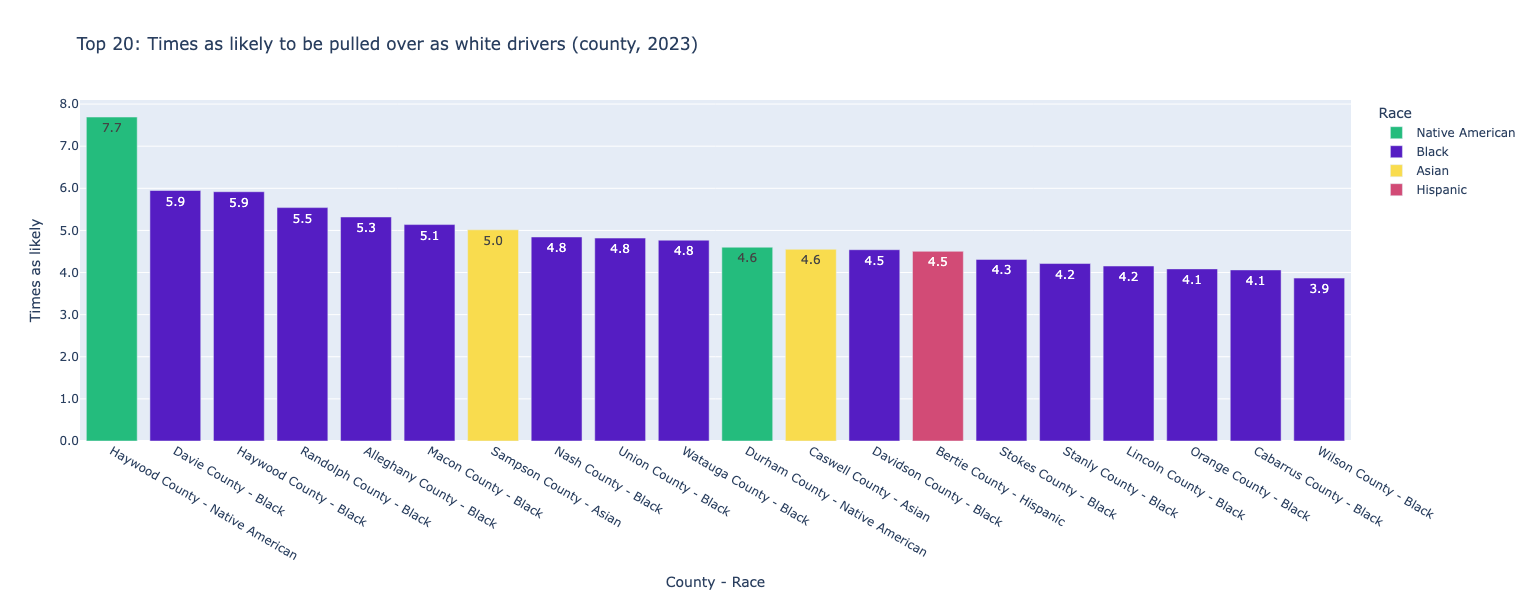

In [14]:
curr_df = df_county_2023[df_county_2023["driver_race"] != "White"].head(20)

fig = px.bar(
    curr_df,
    x="agency_name_race",
    y="times_likely",
    color="driver_race",
    color_discrete_map=color_map,
    title="Top 20: Times as likely to be pulled over as white drivers (county, 2023)",
    labels={
        "times_likely": "Times as likely",
        "driver_race": "Race",
        "agency_name_race": "County - Race",
    },
    text="times_likely",
    text_auto=",.1f",
    height=600,
    category_orders={"agency_name_race": curr_df["agency_name_race"].tolist()},
)
display(fig.update_yaxes(tickformat=",.1f").update_traces(textangle=0))

In [15]:
curr_df.drop(columns=["agency_name_race"])

,level,group_id,group_name,census_profile_id,year,driver_race,population,total_population,stops,stop_rate,baseline_rate,stop_rate_ratio,times_likely
0,county,37087,Haywood County,0500000US37087,2023,Native American,257,59938,70,0.272374,0.035412,6.691553,7.691553
1,county,37059,Davie County,0500000US37059,2023,Black,2419,41764,462,0.190988,0.032111,4.947720,5.947720
2,county,37087,Haywood County,0500000US37087,2023,Black,563,59938,118,0.209591,0.035412,4.918651,5.918651
3,county,37151,Randolph County,0500000US37151,2023,Black,8046,142471,2227,0.276783,0.049950,4.541177,5.541177
4,county,37005,Alleghany County,0500000US37005,2023,Black,176,10996,15,0.085227,0.016024,4.318627,5.318627
5,county,37113,Macon County,0500000US37113,2023,Black,400,34594,39,0.097500,0.018976,4.138151,5.138151
6,county,37163,Sampson County,0500000US37163,2023,Asian,300,62629,5,0.016667,0.003324,4.013889,5.013889
7,county,37127,Nash County,0500000US37127,2023,Black,36427,94622,5876,0.161309,0.033302,3.843831,4.843831
8,county,37179,Union County,0500000US37179,2023,Black,24725,216866,3289,0.133023,0.027610,3.817990,4.817990
9,county,37189,Watauga County,0500000US37189,2023,Black,763,52378,135,0.176933,0.037108,3.768066,4.768066
